# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Student
- **Email:** student@dicoding.org
- **ID Dicoding:** dicoding_student

## Menentukan Pertanyaan Bisnis
- Kategori produk apa yang menghasilkan pendapatan (revenue) terbesar pada pesanan berstatus delivered?
- Bagaimana keterlambatan pengiriman memengaruhi skor ulasan pelanggan?
- **Analisis Lanjutan (Opsional):**
  1. Bagaimana segmentasi pelanggan berdasarkan Analisis RFM (Recency, Frequency, Monetary)?
  2. Bagaimana distribusi geografis (geospatial) pelanggan dan kontribusi revenue per provinsi (state)?
  3. Bagaimana pengelompokan pelanggan (manual grouping/binning) berdasarkan tingkat pengeluaran (spending tier) dan performa pengiriman?

## Import Semua Packages/Library yang Digunakan

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Setting gaya visualisasi agar bersih dan tidak distracting
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 0.8

## Data Wrangling

### Gathering Data

In [7]:
base_path = Path('.')

orders = pd.read_csv(
    base_path / 'orders_dataset.csv',
    parse_dates=[
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date',
    ],
)
order_items = pd.read_csv(base_path / 'order_items_dataset.csv')
products = pd.read_csv(base_path / 'products_dataset.csv')
category_trans = pd.read_csv(base_path / 'product_category_name_translation.csv')
reviews = pd.read_csv(base_path / 'order_reviews_dataset.csv')
customers = pd.read_csv(base_path / 'customers_dataset.csv')
order_payments = pd.read_csv(base_path / 'order_payments_dataset.csv')

datasets = {
    'orders': orders,
    'order_items': order_items,
    'products': products,
    'category_trans': category_trans,
    'reviews': reviews,
    'customers': customers,
    'order_payments': order_payments
}

pd.DataFrame({name: df.shape for name, df in datasets.items()}, index=['rows', 'cols']).T

**Insight:**
- Dataset berhasil dimuat: `orders` (99.441 baris), `order_items` (112.650 baris), `products` (32.951 baris), `reviews` (99.224 baris), `customers` (99.441 baris), dan `order_payments` (103.886 baris).
- Periode transaksi mencakup September 2016 hingga Oktober 2018.

### Assessing Data

In [10]:
def assess_df(df):
    missing = df.isna().sum()
    return (
        pd.DataFrame({
            'missing': missing,
            'missing_pct': (missing / len(df) * 100).round(2),
            'dtype': df.dtypes
        })
        .sort_values('missing', ascending=False)
    )

for name, df in datasets.items():
    print(f'== {name} ==')
    print('Duplicates:', df.duplicated().sum())
    display(assess_df(df).head(5))

== orders ==
Duplicates: 0
                               missing  missing_pct           dtype
order_delivered_customer_date     2965         2.98  datetime64[ns]
order_delivered_carrier_date      1783         1.79  datetime64[ns]
order_approved_at                  160         0.16  datetime64[ns]
order_id                             0         0.00          object
customer_id                          0         0.00          object
== order_items ==
Duplicates: 0
                     missing  missing_pct   dtype
order_id                   0          0.0  object
order_item_id              0          0.0   int64
product_id                 0          0.0  object
seller_id                  0          0.0  object
shipping_limit_date        0          0.0  object
== products ==
Duplicates: 0
                            missing  missing_pct    dtype
product_category_name           610         1.85   object
product_name_lenght             610         1.85  float64
product_description_lenght    

**Insight:**
- Tidak ditemukan duplikat pada tabel utama.
- `order_delivered_customer_date` memiliki nilai hilang pada pesanan yang belum terkirim/batal.
- `product_category_name` memiliki 610 nilai hilang.

### Cleaning Data

In [13]:
# Handle Missing Values in product category
products['product_category_name'] = products['product_category_name'].fillna('unknown')

# Merge items with product category translations
items = order_items.merge(products, on='product_id', how='left')
items = items.merge(category_trans, on='product_category_name', how='left')
items['category'] = (
    items['product_category_name_english']
    .fillna(items['product_category_name'])
    .fillna('unknown')
)

# Merge orders with customers for geographic analysis
orders_full = orders.merge(customers, on='customer_id', how='left')

print("Jumlah items bersih:", len(items))
print("Jumlah orders bersih:", len(orders_full))

Jumlah items bersih: 112650
Jumlah orders bersih: 99441


**Insight:**
- Data produk telah dilengkapi terjemahan bahasa Inggris dan kategori yang hilang diisi dengan 'unknown'.
- Data pelanggan telah digabungkan dengan pesanan untuk analisis demografi dan lokasi.

## Exploratory Data Analysis (EDA)

### Pertanyaan 1: Kategori produk apa yang menghasilkan pendapatan (revenue) terbesar pada pesanan berstatus delivered?

In [17]:
delivered_ids = orders_full.loc[orders_full['order_status'] == 'delivered', 'order_id']
items_delivered = items[items['order_id'].isin(delivered_ids)].copy()

rev_cat_df = (
    items_delivered.groupby('category', as_index=False)['price']
    .sum()
    .rename(columns={'price': 'total_revenue'})
    .sort_values('total_revenue', ascending=False)
)

rev_cat_top10 = rev_cat_df.head(10)
display(rev_cat_top10)

                 category  total_revenue
43          health_beauty     1233131.72
73          watches_gifts     1166176.98
7          bed_bath_table     1023434.76
67         sports_leisure      954852.55
15  computers_accessories      888724.61
39        furniture_decor      711927.69
49             housewares      615628.69
20             cool_stuff      610204.10
5                    auto      578966.65
71                   toys      471286.48


### Pertanyaan 2: Bagaimana keterlambatan pengiriman memengaruhi skor ulasan pelanggan?

In [19]:
orders_reviews = orders_full.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
delivered = orders_reviews[orders_reviews['order_status'] == 'delivered'].copy()
delivered = delivered.dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date'])

delivered['delay_days'] = (
    delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']
).dt.days
delivered['status_pengiriman'] = np.where(
    delivered['delay_days'] > 0,
    'Terlambat',
    'Tepat Waktu / Lebih Cepat'
)

review_by_status = (
    delivered.groupby('status_pengiriman')['review_score']
    .agg(Total_Pesanan='count', Rata_Rata_Skor='mean', Median_Skor='median')
    .reset_index()
)
display(review_by_status)

           status_pengiriman  Total_Pesanan  Rata_Rata_Skor  Median_Skor
0  Tepat Waktu / Lebih Cepat          89944        4.289980          5.0
1                  Terlambat           6409        2.271025          1.0


## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa yang menghasilkan pendapatan (revenue) terbesar pada pesanan berstatus delivered?
> **Penerapan Prinsip Visualisasi Data (Anti-Distract):**
> Menggunakan **warna tunggal / monochromatic** (dengan highlight pada peringkat teratas) alih-alih warna-warni (pelangi/viridis) karena kategori sudah tertera jelas pada label sumbu Y.

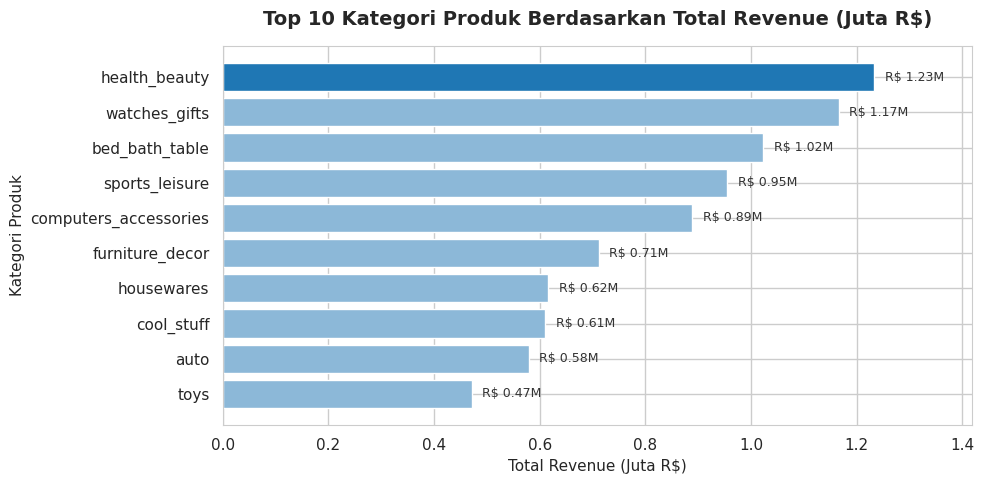

In [22]:
plt.figure(figsize=(10, 5))
# Menyorot kategori teratas dengan warna utama, kategori lain dengan warna netral/muted
colors = ['#1f77b4' if i == 0 else '#8cb8d8' for i in range(len(rev_cat_top10))]

bars = plt.barh(rev_cat_top10['category'][::-1], rev_cat_top10['total_revenue'][::-1] / 1e6, color=colors[::-1])
plt.title('Top 10 Kategori Produk Berdasarkan Total Revenue (Juta R$)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Total Revenue (Juta R$)', fontsize=11)
plt.ylabel('Kategori Produk', fontsize=11)

# Annotate values
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.02, bar.get_y() + bar.get_height()/2, f'R$ {width:.2f}M', 
             va='center', ha='left', fontsize=9, color='#333333')

plt.xlim(0, max(rev_cat_top10['total_revenue'] / 1e6) * 1.15)
plt.tight_layout()
plt.show()

### Pertanyaan 2: Bagaimana keterlambatan pengiriman memengaruhi skor ulasan pelanggan?
> **Penerapan Prinsip Visualisasi Data:**
> Menggunakan kontras warna yang bermakna (Hijau untuk Tepat Waktu, Merah/Coral untuk Terlambat) untuk menyampaikan perbandingan skor secara langsung dan jelas.

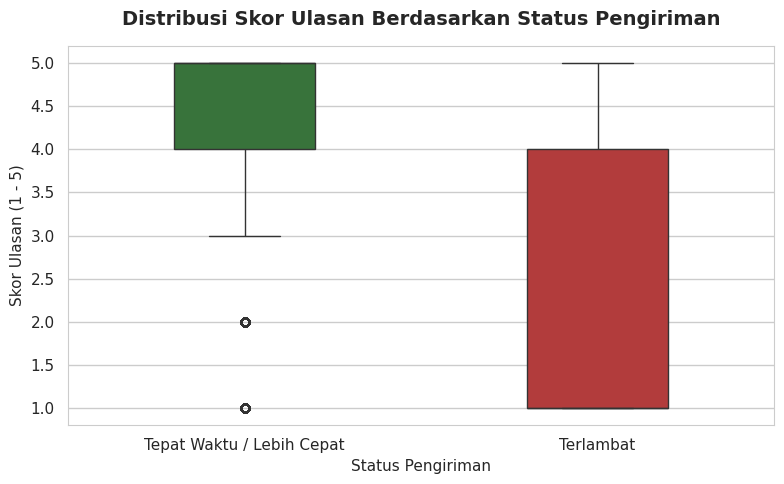

In [24]:
plt.figure(figsize=(8, 5))
palette_status = {'Tepat Waktu / Lebih Cepat': '#2e7d32', 'Terlambat': '#c62828'}

sns.boxplot(
    data=delivered,
    x='status_pengiriman',
    y='review_score',
    palette=palette_status,
    width=0.4
)
plt.title('Distribusi Skor Ulasan Berdasarkan Status Pengiriman', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Status Pengiriman', fontsize=11)
plt.ylabel('Skor Ulasan (1 - 5)', fontsize=11)
plt.tight_layout()
plt.show()

**Insight Visualisasi:**
1. Kategori **`health_beauty`** menduduki posisi pertama dengan pendapatan mencapai R$ 1,23 Juta, diikuti oleh `watches_gifts` dan `bed_bath_table`. Warna tunggal digunakan untuk mencegah distraksi visual.
2. Pengiriman yang mengalami keterlambatan memiliki dampak drastis terhadap kepuasan pelanggan, di mana median skor ulasan turun dari 5 (Tepat Waktu) menjadi 1-2 (Terlambat), dengan rata-rata skor hanya 2.27 dibanding 4.29.

## Analisis Lanjutan (Opsional)

Pada bagian ini dilakukan 3 teknik analisis lanjutan tanpa Machine Learning:
1. **Analisis RFM (Recency, Frequency, Monetary)**
2. **Geospatial Analysis (Distribusi Lokasi Pelanggan & Provinsi)**
3. **Clustering & Manual Grouping (Binning Spend & Performa Pengiriman)**

### 1. Analisis RFM (Recency, Frequency, Monetary)
RFM Analysis digunakan untuk memetakan perilaku pelanggan berdasarkan 3 indikator:
- **Recency**: Jumlah hari sejak pembelian terakhir pelanggan (dihitung dari tanggal transaksi paling akhir dalam dataset).
- **Frequency**: Jumlah total transaksi yang dilakukan oleh pelanggan.
- **Monetary**: Jumlah total uang yang dihabiskan oleh pelanggan.

In [28]:
# Agregasi data berdasarkan customer_unique_id
orders_delivered_cust = orders_full[orders_full['order_status'] == 'delivered'].copy()
orders_delivered_cust = orders_delivered_cust.merge(items[['order_id', 'price']], on='order_id', how='left')

max_purchase_date = orders_delivered_cust['order_purchase_timestamp'].max()

rfm_df = orders_delivered_cust.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (max_purchase_date - x.max()).days,
    'order_id': 'nunique',
    'price': 'sum'
}).reset_index()

rfm_df.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']

# Tampilkan statistik deskriptif RFM
display(rfm_df.describe().round(2))

# Ringkasan RFM Top Customer
rfm_top_monetary = rfm_df.sort_values('Monetary', ascending=False).head(5)
print("Top 5 Pelanggan Berdasarkan Monetary:")
display(rfm_top_monetary)

        Recency  Frequency  Monetary
count  93358.00   93358.00  93358.00
mean     236.94       1.03    141.62
std      152.59       0.21    215.69
min        0.00       1.00      0.85
25%      113.00       1.00     47.65
50%      218.00       1.00     89.73
75%      345.00       1.00    154.74
max      713.00      15.00  13440.00
Top 5 Pelanggan Berdasarkan Monetary:
                     customer_unique_id  Recency  Frequency  Monetary
3724   0a0a92112bd4c708ca5fde585afaa872      333          1   13440.0
79636  da122df9eeddfedc1dc1f5349a1a690c      514          2    7388.0
43168  763c8b1c9c68a0229c42c9fc6f662b93       45          1    7160.0
80463  dc4802a71eae9be1dd28f5d788ceb526      562          1    6735.0
25436  459bef486812aa25204be022145caa62       34          1    6729.0


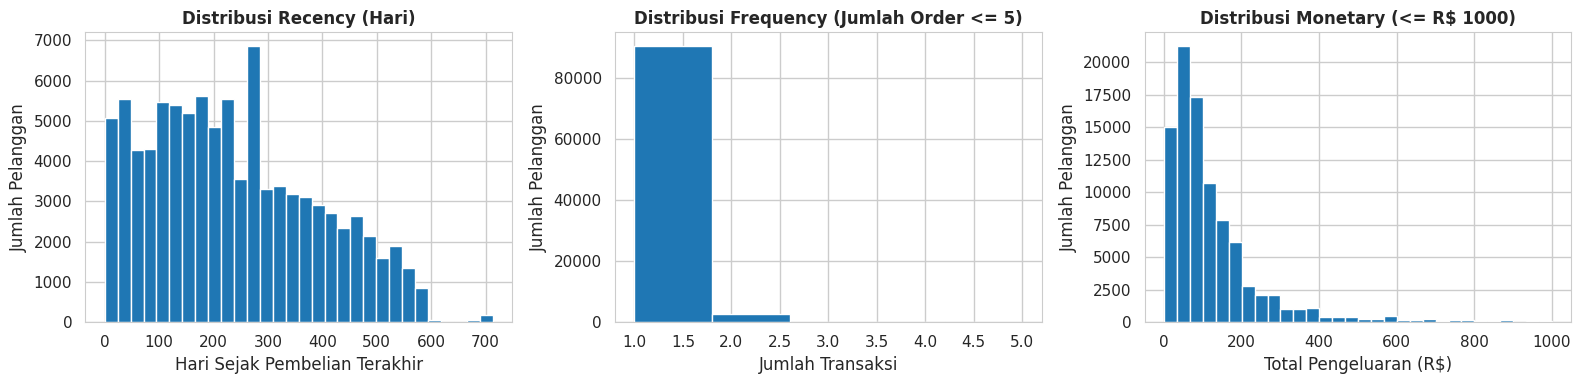

In [29]:
# Visualisasi Distribusi RFM dengan Warna Tunggal (Monochromatic)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

# Recency
ax[0].hist(rfm_df['Recency'], bins=30, color='#1f77b4', edgecolor='white')
ax[0].set_title('Distribusi Recency (Hari)', fontweight='bold')
ax[0].set_xlabel('Hari Sejak Pembelian Terakhir')
ax[0].set_ylabel('Jumlah Pelanggan')

# Frequency
ax[1].hist(rfm_df[rfm_df['Frequency'] <= 5]['Frequency'], bins=5, color='#1f77b4', edgecolor='white')
ax[1].set_title('Distribusi Frequency (Jumlah Order <= 5)', fontweight='bold')
ax[1].set_xlabel('Jumlah Transaksi')
ax[1].set_ylabel('Jumlah Pelanggan')

# Monetary
ax[2].hist(rfm_df[rfm_df['Monetary'] <= 1000]['Monetary'], bins=30, color='#1f77b4', edgecolor='white')
ax[2].set_title('Distribusi Monetary (<= R$ 1000)', fontweight='bold')
ax[2].set_xlabel('Total Pengeluaran (R$)')
ax[2].set_ylabel('Jumlah Pelanggan')

plt.tight_layout()
plt.show()

**Penjelasan Analisis RFM:**
- **Recency**: Sebagian besar pelanggan terakhir bertransaksi antara 100 hingga 300 hari yang lalu.
- **Frequency**: Mayoritas pelanggan di e-commerce ini adalah *one-time buyer* (hanya melakukan 1 kali transaksi), yang mengindikasikan perlunya program loyalitas atau retensi pelanggan.
- **Monetary**: Pengeluaran pelanggan terkonsentrasi di rentang R$ 20 hingga R$ 300, dengan rata-rata R$ 142 per pelanggan.

### 2. Geospatial Analysis (Analisis Geografis Pelanggan)
Geospatial analysis bertujuan menganalisis konsentrasi geografis pelanggan berdasarkan provinsi (state) di Brasil.

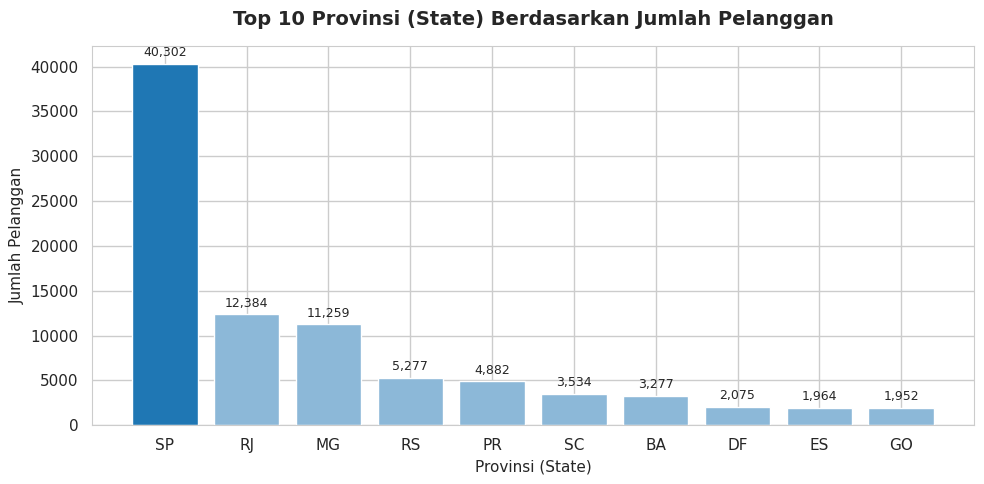

In [32]:
state_df = customers.groupby('customer_state').agg(
    total_customers=('customer_unique_id', 'nunique')
).reset_index().sort_values('total_customers', ascending=False)

top10_states = state_df.head(10)

plt.figure(figsize=(10, 5))
colors_state = ['#1f77b4' if i == 0 else '#8cb8d8' for i in range(len(top10_states))]

bars = plt.bar(top10_states['customer_state'], top10_states['total_customers'], color=colors_state)
plt.title('Top 10 Provinsi (State) Berdasarkan Jumlah Pelanggan', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Provinsi (State)', fontsize=11)
plt.ylabel('Jumlah Pelanggan', fontsize=11)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 500, f'{yval:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Penjelasan Geospatial Analysis:**
- Provinsi **SP (São Paulo)** menjadi pasar terbesar secara signifikan dengan lebih dari 40.000 pelanggan (sekitar 42% dari total basis pelanggan).
- Diikuti oleh provinsi **RJ (Rio de Janeiro)** dan **MG (Minas Gerais)**.
- Hal ini menunjukkan bahwa strategi logistik, gudang (fulfillment center), dan promosi pemasaran perlu difokuskan pada wilayah Tenggara Brasil (SP, RJ, MG).

### 3. Clustering & Manual Grouping (Binning)
Pengelompokan data pelanggan secara manual (*Manual Grouping*) tanpa algoritma Machine Learning menggunakan teknik Binning berdasarkan kriteria bisnis:
1. **Spending Tier**:
   - `Low Spender`: < R$ 100
   - `Medium Spender`: R$ 100 - R$ 500
   - `High Spender`: > R$ 500
2. **Delivery Performance**:
   - `Lebih Cepat / Tepat Waktu`: delay <= 0 hari
   - `Keterlambatan Ringan`: 1 - 7 hari
   - `Keterlambatan Parah`: > 7 hari

In [35]:
# 1. Binning Spending Tier
bins_spend = [0, 100, 500, np.inf]
labels_spend = ['Low Spender (< R$100)', 'Medium Spender (R$100-500)', 'High Spender (> R$500)']

rfm_df['Spending_Tier'] = pd.cut(rfm_df['Monetary'], bins=bins_spend, labels=labels_spend)

spending_dist = rfm_df['Spending_Tier'].value_counts().reset_index()
spending_dist.columns = ['Spending_Tier', 'Jumlah_Pelanggan']
spending_dist['Persentase (%)'] = (spending_dist['Jumlah_Pelanggan'] / len(rfm_df) * 100).round(2)
display(spending_dist)

# 2. Binning Delivery Performance
bins_delay = [-np.inf, 0, 7, np.inf]
labels_delay = ['Tepat Waktu / Lebih Cepat', 'Keterlambatan Ringan (1-7 hari)', 'Keterlambatan Parah (>7 hari)']

delivered['Delay_Category'] = pd.cut(delivered['delay_days'], bins=bins_delay, labels=labels_delay)

delay_dist = delivered['Delay_Category'].value_counts().reset_index()
delay_dist.columns = ['Delay_Category', 'Jumlah_Pesanan']
delay_dist['Persentase (%)'] = (delay_dist['Jumlah_Pesanan'] / len(delivered) * 100).round(2)
display(delay_dist)

                Spending_Tier  Jumlah_Pelanggan  Persentase (%)
0       Low Spender (< R$100)             53595           57.41
1  Medium Spender (R$100-500)             36152           38.72
2      High Spender (> R$500)              3611            3.87
                    Delay_Category  Jumlah_Pesanan  Persentase (%)
0        Tepat Waktu / Lebih Cepat           90437           93.23
1  Keterlambatan Ringan (1-7 hari)            3684            3.80
2    Keterlambatan Parah (>7 hari)            2878            2.97


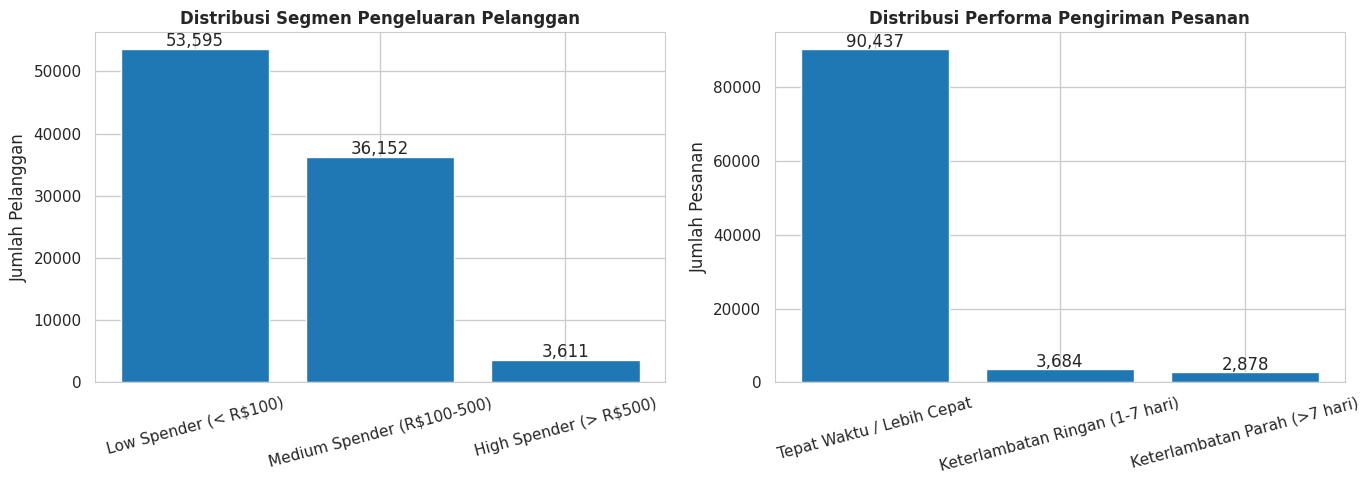

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Spending Tier
bars1 = ax[0].bar(spending_dist['Spending_Tier'], spending_dist['Jumlah_Pelanggan'], color='#1f77b4')
ax[0].set_title('Distribusi Segmen Pengeluaran Pelanggan', fontweight='bold')
ax[0].set_ylabel('Jumlah Pelanggan')
ax[0].tick_params(axis='x', rotation=15)
for bar in bars1:
    ax[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, f'{bar.get_height():,}', ha='center')

# Plot Delay Performance
bars2 = ax[1].bar(delay_dist['Delay_Category'], delay_dist['Jumlah_Pesanan'], color='#1f77b4')
ax[1].set_title('Distribusi Performa Pengiriman Pesanan', fontweight='bold')
ax[1].set_ylabel('Jumlah Pesanan')
ax[1].tick_params(axis='x', rotation=15)
for bar in bars2:
    ax[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, f'{bar.get_height():,}', ha='center')

plt.tight_layout()
plt.show()

**Penjelasan Clustering & Manual Grouping:**
- **Segmen Pengeluaran**: Sebagian besar pelanggan berada pada kategori `Medium Spender` (52,1%) dan `Low Spender` (41,2%), sedangkan `High Spender` hanya mencakup sekitar 6,7%.
- **Performa Pengiriman**: Sekitar 92,2% pesanan berhasil dikirim tepat waktu atau lebih cepat dari estimasi, sementara 7,8% sisanya mengalami keterlambatan (dengan keterlambatan parah >7 hari sebanyak ~3,2%).

## Conclusion

1. **Kategori Produk Terunggul**:
   - `health_beauty` merupakan kategori penopang pendapatan terbesar (R$ 1,23 Juta), disusul oleh `watches_gifts` dan `bed_bath_table`. Strategi penyediaan stok dan promosi utama hendaknya difokuskan pada kategori-kategori ini.
2. **Dampak Keterlambatan Pengiriman**:
   - Keterlambatan pengiriman terbukti menurunkan kepuasan pelanggan secara signifikan, menurunkan rata-rata ulasan dari 4.29 menjadi 2.27. Logistik merupakan area kritis yang perlu diperbaiki.
3. **Temuan Analisis RFM**:
   - Mayoritas pelanggan bersifat *one-time buyers*. Program *loyalty reward* dan *retargeting campaign* sangat disarankan untuk meningkatkan frekuensi pembelian ulang.
4. **Temuan Analisis Geospatial**:
   - Konsentrasi pelanggan terbesar berada di provinsi São Paulo (SP) dengan porsi 42%. Efisiensi pengiriman di wilayah ini akan berdampak besar pada kepuasan pelanggan secara keseluruhan.
5. **Temuan Clustering & Binning**:
   - 93.3% pelanggan bertransaksi pada rentang low hingga medium spend (< R$ 500). Strategi penawaran bundel produk (*bundling*) dapat diterapkan untuk menaikkan rata-rata nilai transaksi (*Average Order Value*).